## Модели классификации для нескольких классов

Ирисы Фишера - самый популярный в статистической литературе набор данных, часто используемый для иллюстрации работы различных алгоритмов классификации.

Выборка состоит из 150 экземпляров ирисов трех видов, для которых измерялись четыре характеристики: длина и ширина чашелистика (Sepal.Length и Sepal.Width), длина и ширина лепестка (Petal.Length и Petal.Width). Требуется на основе этого набора данных, построить различные модели многоклассовой классификации, оценивающие каждый из трех видов растения по данным проведенных измерений.

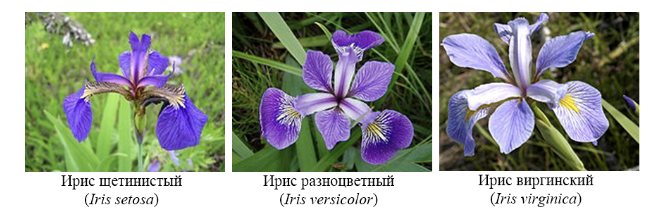

Импортируем необходимые библиотеки:

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import accuracy_score, rand_score, confusion_matrix
from scipy.optimize import linear_sum_assignment

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

Библиотека Scikit-Learn предоставляет чистые датасеты, которые вы можете использовать при построении моделей машинного обучения. Они поставляются вместе с Scikit-Learn (https://scikit-learn.ru/7-1-toy-datasets/).

Набор данных Iris, классический набор данных в машинном обучении и статистике. Он входит в модуль datasets библиотеки scikit-learn и загрузить его можно, вызвав функцию load_iris().

In [3]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['name'] = iris_df.target.apply(lambda x : iris.target_names[x])

In [4]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Набор данных состоит из длины/ширины двух типов лепестков Ириса: sepal и petal.

Целевая переменная — это сорт Ириса: 0 — Setosa, 1 — Versicolor, 2 — Virginica. 

Соответственно, наша задача — по имеющимся данным попробовать найти зависимости между размерами лепестков и сортами Ирисов.

Объект Bunch — это словарь, который предоставляет свои ключи как атрибуты.

Формируем DataFrame:

In [6]:
iris_df = pd.DataFrame(iris.data)

In [4]:
iris_df.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# Делаем имена колонок такие же, как имена переменных:
iris_df.columns = iris.feature_names
# Добавляем столбец с целевой переменной: 
iris_df['target'] = iris.target
# Для наглядности добавляем столбец с сортами: 
iris_df['name'] = iris_df.target.apply(lambda x : iris.target_names[x])
iris_df.head()

ValueError: Length mismatch: Expected axis has 6 elements, new values have 4 elements

In [6]:
iris_df.shape

(150, 6)

In [152]:
# информация о наборе данных
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
 5   name               150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB


In [154]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [156]:
iris_df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [158]:
iris_df['name'].value_counts()

name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Описательная статистика

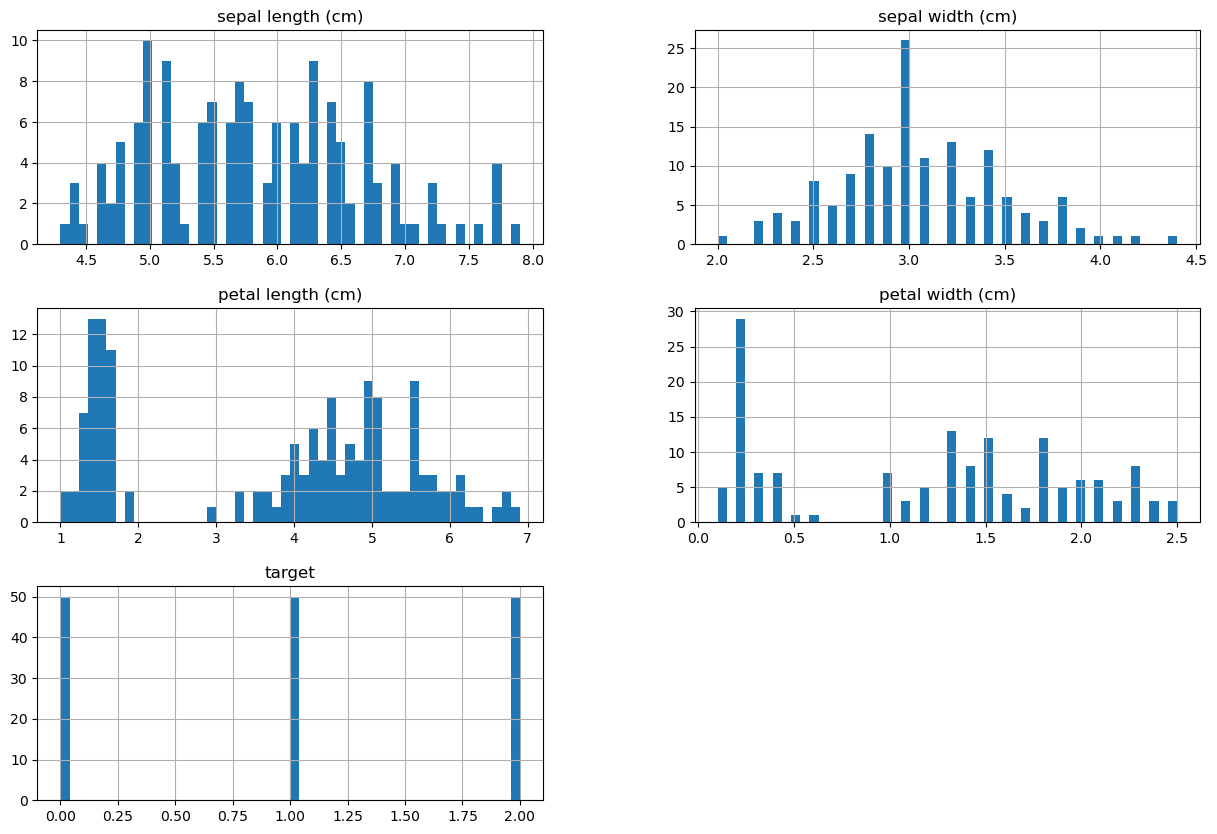

In [60]:
iris_df.hist(figsize = (15,10), bins = 50);

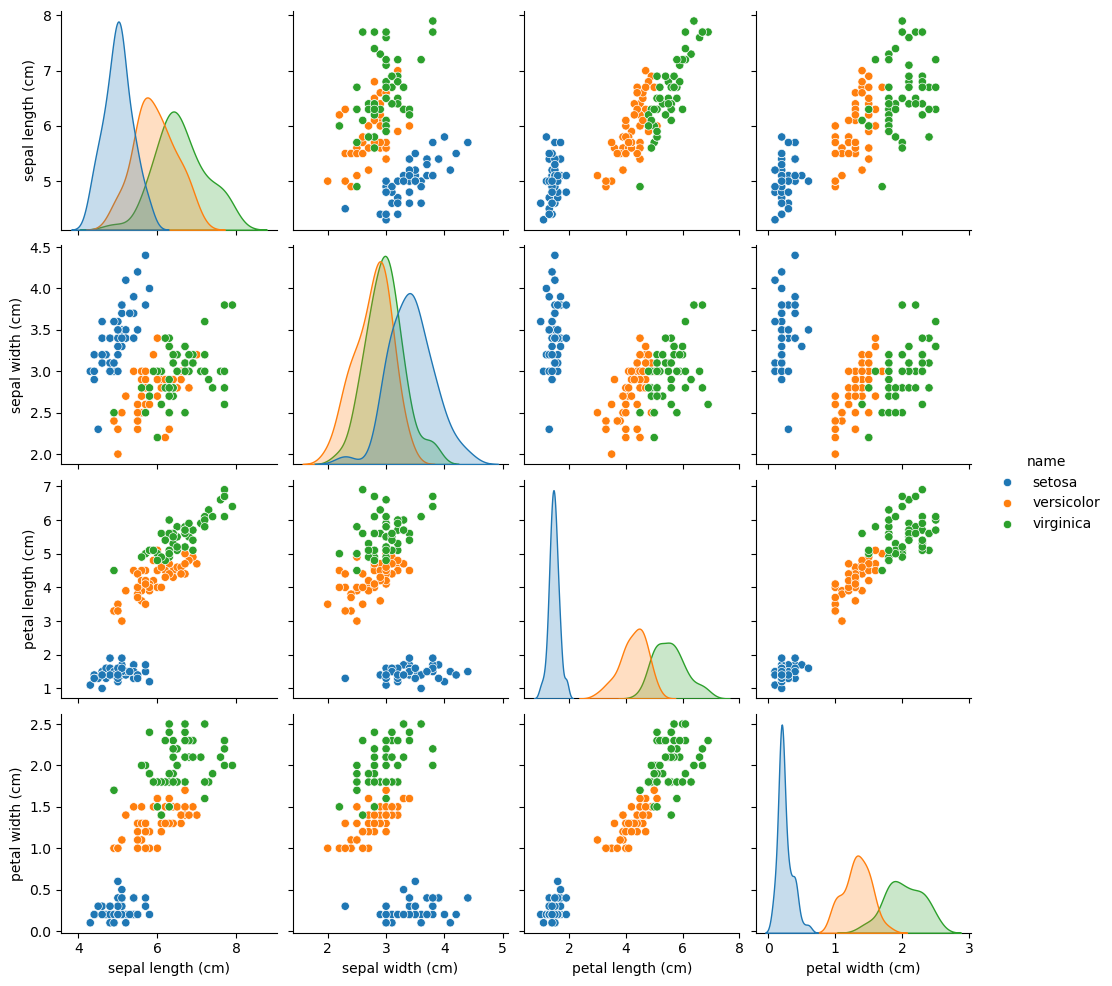

In [42]:
sns.pairplot(iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)','name']], hue = 'name')

Видно, что «petal width (cm)» и «petal length (cm)» имеют сильную зависимость — точки вытянуты вдоль одной линии. И в принципе по этим же признакам можно строить классификацию, т.к. точки по цвету сгруппированы достаточно компактно. А вот, например, с помощью переменных «sepal width (cm)» и «sepal length (cm)» качественную классификацию не построить, т.к. точки, относящиеся к сортам Versicolor и Virginica, перемешаны между собой.

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

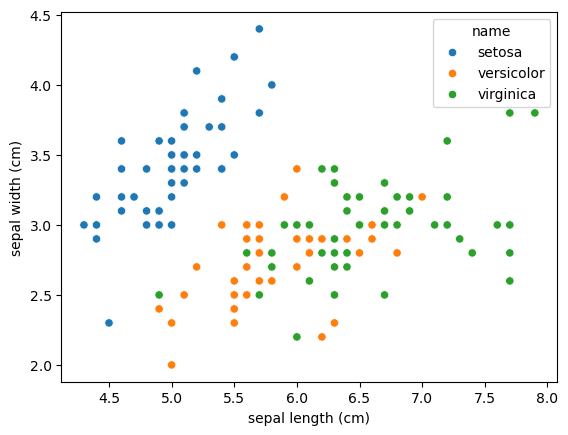

In [45]:
sns.scatterplot(data=iris_df, x="sepal length (cm)", y="sepal width (cm)", hue="name")

In [7]:
corr = iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']].corr()
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


<Axes: >

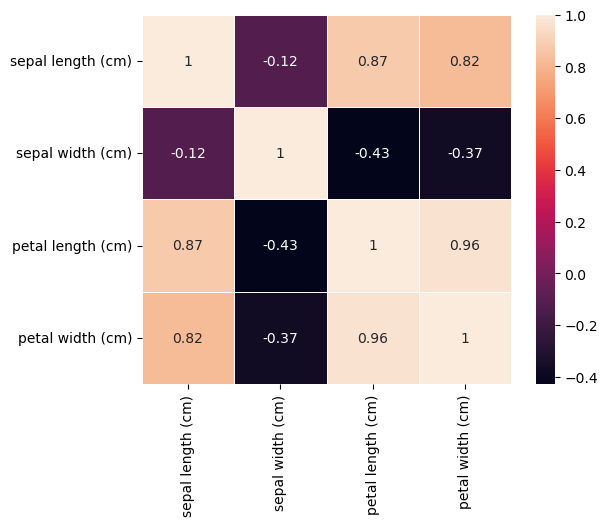

In [163]:
sns.heatmap(corr, square=True, annot=True, linewidths=.5)

Действительно видим, что между переменными «petal length (cm)» и «petal width (cm)» выявлена очень сильная зависимость 0.96, а между «sepal width (cm)» и «sepal length (cm)» - слабая корреляция.

### Обучение классификатора

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']], 
                                                      iris_df['target'], 
                                                      test_size=0.3, 
                                                      random_state=19)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

In [10]:
# Обучаем модель на обучающей выборке
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [11]:
y_pred = knn.predict(X_test)
y_pred

array([0, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 2, 0, 2, 0, 1, 0, 1, 1,
       1, 1, 2, 1, 2, 2, 1, 2, 0, 1, 2, 1, 1, 0, 0, 0, 2, 2, 1, 2, 1, 2,
       2])

In [12]:
# Другой способ для вычисления метрики
from sklearn.metrics import accuracy_score
basic_accuracy=accuracy_score(y_test, y_pred)
basic_accuracy

0.9333333333333333

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.94      0.91        16
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.94        45
weighted avg       0.93      0.93      0.93        45



### Confusion Matrix

In [14]:
from sklearn.metrics import confusion_matrix

In [15]:
conf_matrix = confusion_matrix(y_test, y_pred)

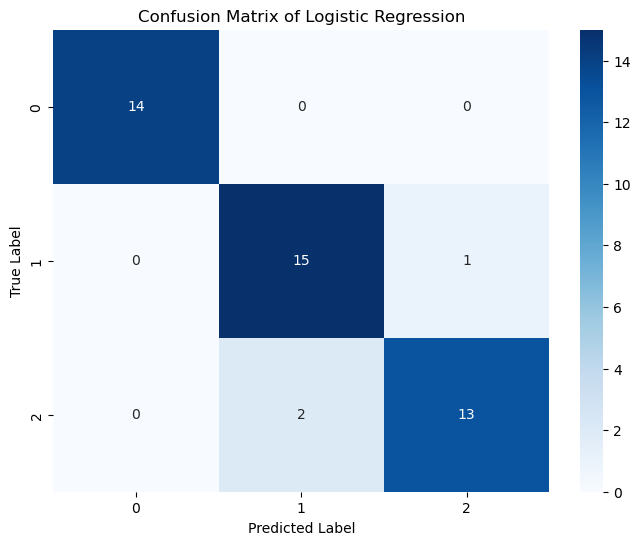

In [72]:
Y = iris_df['target']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(Y), yticklabels=np.unique(Y))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Logistic Regression')
plt.show()

### Метрики многоклассовой классификации

1) Микро-усреднение (micro-averaging) является эквивалентом accuracy и подходит __при сбалансированных классах__. Элементы consufion matrix усредняются между бинарными прогнозами для каждого класса, после чего метрики рассчитываются на полученной матрице. На примере Precision и Recall это выглядит следующим образом:

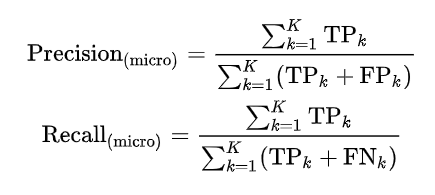

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [184]:
print(precision_score(y_test, y_pred, average='micro'))
print(recall_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='micro'))

0.9333333333333333
0.9333333333333333
0.9333333333333333


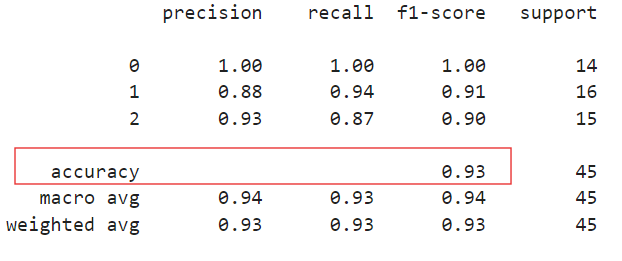

2) Макро-усреднение (macro-averaging) представляет собой среднее арифметическое подсчитанной метрики для каждого класса и используется __при дисбалансе классов, когда важен каждый класс__. В таком случае все классы учитываются равномерно независимо от их размера.

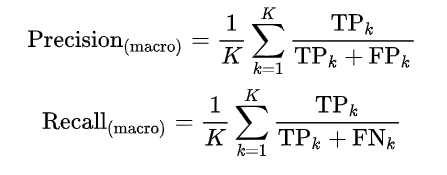

In [187]:
print(precision_score(y_test, y_pred, average='macro'))
print(recall_score(y_test, y_pred, average='macro'))
print(f1_score(y_test, y_pred, average='macro'))

0.9369747899159663
0.9347222222222222
0.9352142110762801


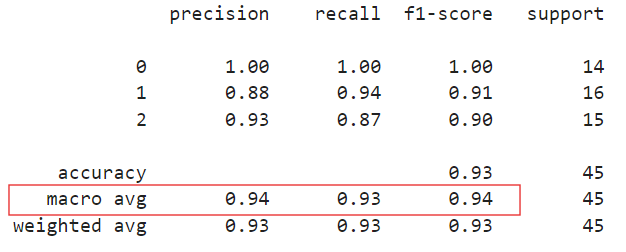

3) Взвешенное усреднение (weighted averaging) рассчитывается как взвешенное среднее и также применяется в случае __дисбаланса классов__, но только когда важность класса учитывается в зависимости от количества объектов с таким классом, то есть __когда важны наибольшие классы__. При таком подходе важность каждого класса учитывается с присвоением им весов. Вес класса w_k может устанавливаться по-разному, например, как доля примеров этого класса в обучающей выборке:

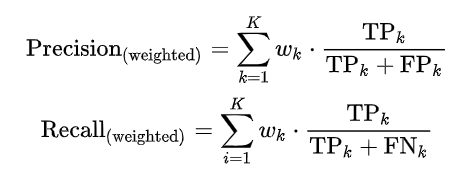

In [189]:
print(precision_score(y_test, y_pred, average='weighted'))
print(recall_score(y_test, y_pred, average='weighted'))
print(f1_score(y_test, y_pred, average='weighted'))

0.9343604108309991
0.9333333333333333
0.9331940090560781


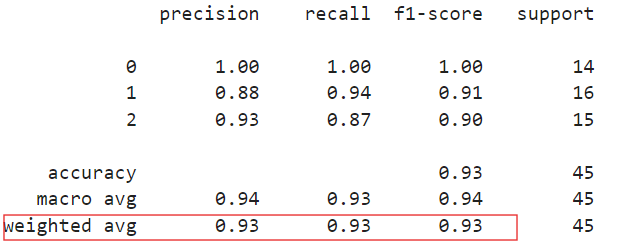

### Кроссвалидация

__Кросс-валидация (перекрестная проверка)__ — это метод оценки производительности модели машинного обучения, который позволяет более эффективно использовать данные для обучения и тестирования. Вместо одного разделения на обучающую и тестовую выборки, мы делаем несколько таких разделений и усредняем результаты.

##### Как работает кросс-валидация

Один из самых распространенных методов — k-блочная кросс-валидация (k-fold cross-validation).

Шаги k-блочной кросс-валидации:
- __Разбиение данных:__ Исходный набор данных случайным образом разбивается на k частей (фолдов) примерно одинакового размера. Обычно k выбирают 5 или 10.

- __Обучение и валидация:__ Модель обучается k раз. Каждый раз:
1. Один из k фолдов используется в качестве тестовой выборки (валидационной).
2. Оставшиеся k-1 фолдов объединяются в обучающую выборку.
3. Модель обучается на обучающей выборке и оценивается на тестовой.
   
- __Сбор метрик:__ После каждого из k запусков вычисляется метрика качества (например, точность). В итоге получаем k значений метрики.

- __Усреднение:__  Вычисляется среднее значение и стандартное отклонение по k метрикам. Это дает итоговую оценку производительности модели.

##### Стратифицированная кросс-валидация
Для задач классификации часто используют стратифицированную кросс-валидацию. Она сохраняет распределение классов в каждом фолде таким же, как и в исходном наборе данных. Это особенно важно, если данные несбалансированы.

In [17]:
X = iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']] 
                                                    

In [18]:
y = iris_df['target']

In [19]:
from sklearn.model_selection import cross_val_score, GridSearchCV, learning_curve

In [20]:
# Cross-validation
cv_scores = cross_val_score(knn, X, y, cv=5)
print('Cross-validation scores: ', cv_scores)
print('Mean cross-validation score: ', np.mean(cv_scores))

Cross-validation scores:  [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Mean cross-validation score:  0.96


### Настройка гиперпараметров

__GridSearch (сеточный поиск)__ - это метод подбора оптимальных гиперпараметров модели машинного обучения путем полного перебора всех возможных комбинаций.

Как работает GridSearch?

- Задаем сетку гиперпараметров: для каждого гиперпараметра указываем список возможных значений.

- Создаем все возможные комбинации этих гиперпараметров.

- Для каждой комбинации:

1. Обучаем модель на обучающих данных.

2. Оцениваем модель с помощью кросс-валидации.

- Выбираем комбинацию, которая показала наилучший результат.

- Обучаем финальную модель на всем обучающем наборе с лучшими найденными гиперпараметрами.

In [21]:
param_grid = {'n_neighbors': [1,2,3,4,5]}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best Parameters: ", grid_search.best_params_)

Best Parameters:  {'n_neighbors': 3}


In [22]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [23]:
y_pred = knn.predict(X_test)
y_pred

array([0, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 2, 0, 2, 0, 1, 0, 1, 1,
       1, 1, 2, 1, 2, 2, 1, 2, 0, 1, 2, 1, 1, 0, 0, 0, 2, 2, 1, 2, 1, 2,
       2])

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.94      0.91        16
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.94        45
weighted avg       0.93      0.93      0.93        45



In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [26]:
y_pred = knn.predict(X_test)
y_pred

array([0, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 2, 0, 2, 0, 1, 0, 1, 1,
       1, 1, 2, 1, 2, 2, 1, 2, 0, 2, 2, 1, 1, 0, 0, 0, 2, 2, 1, 2, 1, 2,
       2])

In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        16
           2       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [28]:
# Определяем сетку параметров для KNN
param_grid = {
    'n_neighbors': list(range(1, 31)),           # количество соседей от 1 до 30
    'weights': ['uniform', 'distance'],          # тип весов
    'metric': ['euclidean', 'manhattan', 'minkowski'],  # метрики расстояния
    'p': [1, 2, 3]                               # параметр для метрики Минковского
}

# Создаем GridSearchCV
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,                    # 5-фолдовая кросс-валидация
    scoring='accuracy',       # метрика для оптимизации
    n_jobs=-1,               # использовать все ядра
    verbose=1,               # вывод прогресса
    return_train_score=True  # возвращать оценки на обучении
)

# Запускаем поиск
print("Запуск GridSearch...")
grid_search.fit(X_train, y_train)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ GRIDSEARCH")
print("="*50)

Запуск GridSearch...
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

РЕЗУЛЬТАТЫ GRIDSEARCH


In [29]:
print("Лучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"Лучшая точность (CV): {grid_search.best_score_:.4f}")



Лучшие параметры:
  metric: euclidean
  n_neighbors: 8
  p: 1
  weights: distance
Лучшая точность (CV): 0.9905


In [30]:
# Оценка на тестовых данных
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Точность на тестовых данных: {test_accuracy:.4f}")

print(f"Улучшение точности: {test_accuracy - basic_accuracy:.4f}")

Точность на тестовых данных: 0.9778
Улучшение точности: 0.0444


## Кластеризация

In [7]:
X = iris_df.drop(['target', 'name'], axis=1)
y = iris_df['target']

In [1]:
# разделил данные на признаки и целевую переменную

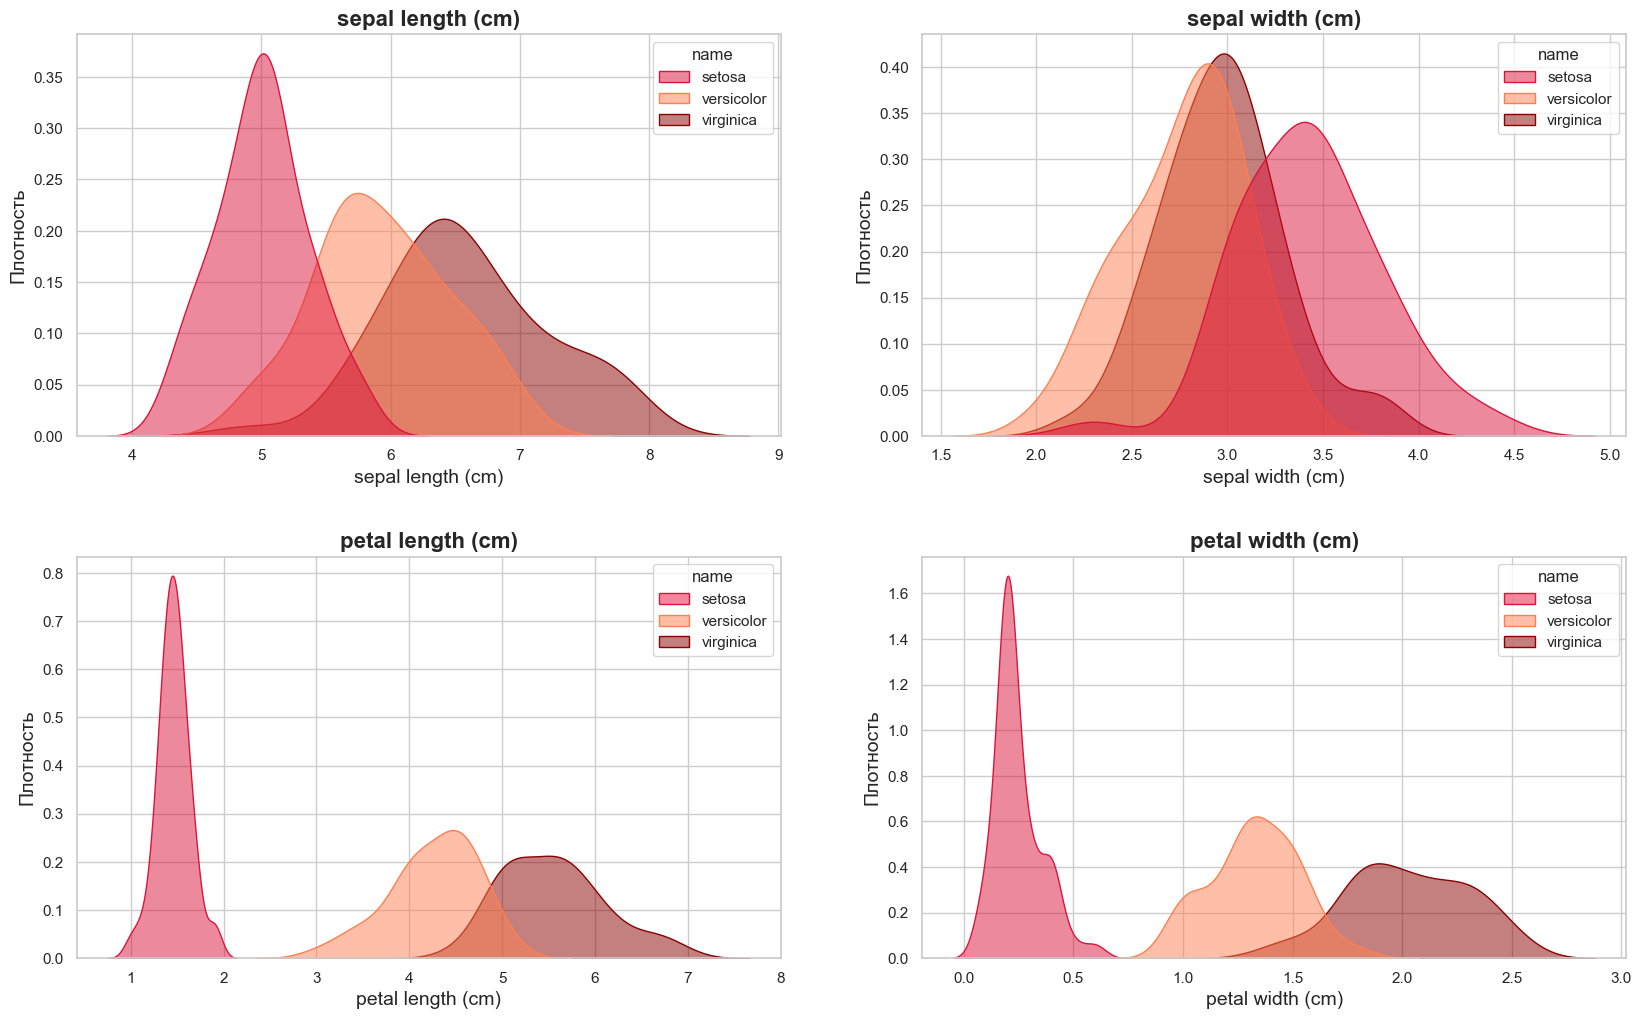

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
plt.subplots_adjust(hspace=0.3)
columns = X.columns

for i, column in enumerate(columns):
    ax = axes[i // 2, i % 2]
    sns.kdeplot(data=iris_df,
                palette=['#DC143C', '#FF7F50', '#8B0000'], 
                x=column,
                fill=True,
                alpha=0.5,
                hue='name',
                ax=ax)
    
    ax.set_title(column, fontweight='bold', fontsize=16)
    ax.set_xlabel(column, fontsize=14)
    ax.set_ylabel('Плотность', fontsize=14)

plt.show()

### 1. Разделимость класса Setosa
На нижних графиках
Setosa стоит отдельно от двух других
### 2. Сравнение признаков: Petal важнее Sepal
Признаки petal length и petal width являются наиболее подходящими для обучения модели. sepal width самый слабый признак

In [14]:
# Нормализация данных 
mms = MinMaxScaler()
X_scaled = pd.DataFrame(mms.fit_transform(X), columns=X.columns)

# PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])


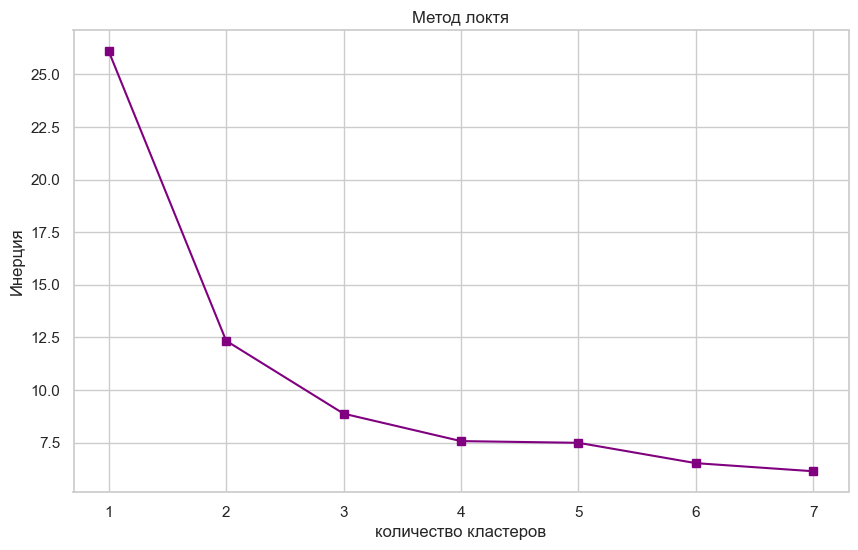

In [10]:
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init='auto').fit(X)
    inertia.append(np.sqrt(kmeans.inertia_))
    
plt.figure(figsize=(10, 6))
plt.plot(range(1, 8), inertia, marker="s", color='purple')
plt.xlabel("количество кластеров")
plt.ylabel("Инерция")
plt.title("Метод локтя")
plt.show()

### Вывод о методе локтя
- От 1 до 2: Линия идет вниз. Значит, что разделение данных на 2 группы дает больше точности
- От 2 до 3: Линия все еще снижается, поэтому еще одно разделение имеет смысл
- Точка 3 (Локоть): Тут происходит "излом"
- От 4 до 7: Линия становится ближе к прямой. Добавление следующих кластеров не сильно будет уменьшать ошибку

### Обучение 3 алгоритмов

In [18]:
# 1. K-Means
kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto')
kmeans.fit(X)
pred_k = kmeans.labels_
centroids_pca = pca.transform(kmeans.cluster_centers_)

# 2. Агломеративная кластеризация
clustering_ward = AgglomerativeClustering(n_clusters=3).fit(X)
pred_ward = clustering_ward.labels_

# 3. Спектральная кластеризация
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=1)
pred_sp = spectral.fit_predict(X)

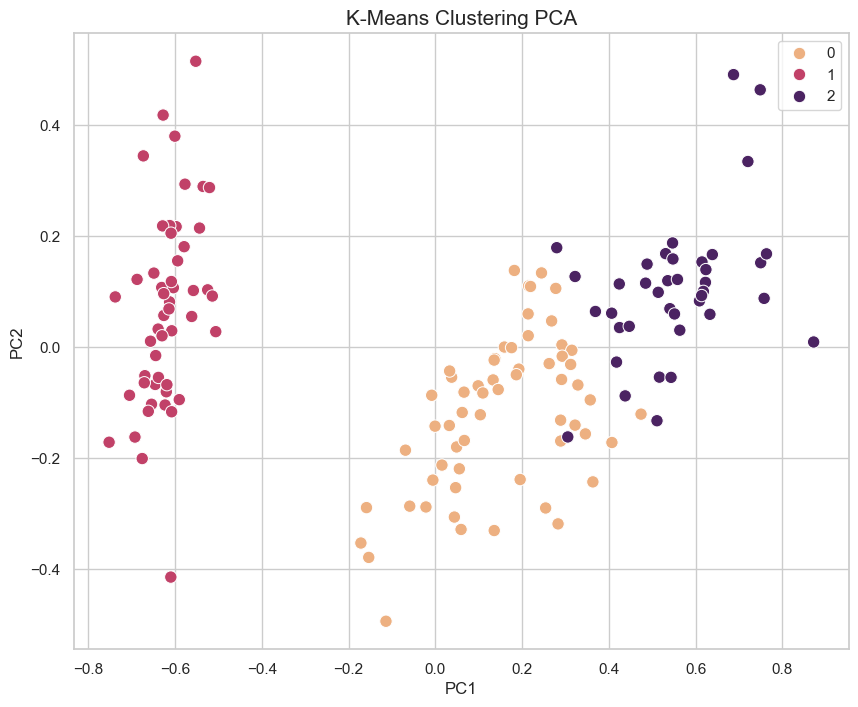

In [17]:
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(x=principal_df['PC1'], 
                y=principal_df['PC2'], 
                hue=pred_k, 
                palette="flare", 
                s=80)
plt.title('Clustering PCA', fontsize=15)
plt.legend()
plt.show()

### Вывод по визуализации:
- Левый кластер — это Setosa. Этот сорт отличается от двух других его точки слева
- Правый кластер — это Versicolor и Virginica и эти два сорта похожи друг на друга

### Расчет метрик

In [19]:
def get_best_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(cm, maximize=True)
    reorder_dict = {col: row for row, col in zip(row_ind, col_ind)}
    y_pred_fixed = [reorder_dict[x] for x in y_pred]
    acc = accuracy_score(y_true, y_pred_fixed)
    correct_count = accuracy_score(y_true, y_pred_fixed, normalize=False)
    return acc, int(correct_count), y_pred_fixed
    
rs_k = rand_score(y, pred_k)
acc_k, corr_k, best_pred_k = get_best_accuracy(y, pred_k)

rs_ward = rand_score(y, pred_ward)
acc_ward, corr_ward, best_pred_ward = get_best_accuracy(y, pred_ward)

rs_sp = rand_score(y, pred_sp)
acc_sp, corr_sp, best_pred_sp = get_best_accuracy(y, pred_sp)
print('\nK-Means Results')
print(f"Rand Score: {rs_k:.4f}")
print(f"Accuracy:   {acc_k:.4f}")
print(f"Верно предсказано: {corr_k} из {len(y)}")

print('\nAgglomerative Clustering Results')
print(f"Rand Score: {rs_ward:.4f}")
print(f"Accuracy:   {acc_ward:.4f}")
print(f"Верно предсказано: {corr_ward} из {len(y)}")

print('\nSpectral Clustering Results')
print(f"Rand Score: {rs_sp:.4f}")
print(f"Accuracy:   {acc_sp:.4f}")
print(f"Верно предсказано: {corr_sp} из {len(y)}")


K-Means Results
Rand Score: 0.8737
Accuracy:   0.8867
Верно предсказано: 133 из 150

Agglomerative Clustering Results
Rand Score: 0.8797
Accuracy:   0.8933
Верно предсказано: 134 из 150

Spectral Clustering Results
Rand Score: 0.8923
Accuracy:   0.9067
Верно предсказано: 136 из 150


## Итог
В ходе работы была выполнена кластеризация набора данных Iris
- EDA: Графики плотности показали, что класс Setosa хорошо отделим от двух других по признакам лепестка petal length и width
- Моделирование: Были применены три алгоритма: K-Means, Agglomerative Clustering и Spectral Clustering
самый лучший результат у Spectral Clustering
- Итог: Методы кластеризации выделили структуру данных, с хорошей точностью 